In [1]:
import sys
path_to_pip_installs = "/tmp/test_env"
if path_to_pip_installs not in sys.path:
    sys.path.insert(0, path_to_pip_installs)

import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
masks_path = "../data/my_data2/test/DIXON_masks.npy"
masks = np.load(masks_path)

In [ ]:



def fill_holes(mask):
    """
    Fills holes in a binary mask and returns a mask with values 0 and 1.
    """
    # Create a copy of the mask to be modified
    holes_mask = mask.copy().astype(np.uint8)
    
    # The mask for floodFill needs a 2-pixel border
    h, w = holes_mask.shape
    ff_mask = np.zeros((h + 2, w + 2), np.uint8)

    # Flood fill the background. After this, the background is 1,
    # the holes are 0, and the foreground is its original non-zero value.
    cv2.floodFill(holes_mask, ff_mask, (0, 0), 1)

    # Isolate the holes. The holes are the only pixels that are still 0.
    # This creates a mask where holes are 1 and everything else is 0.
    just_the_holes = (holes_mask == 0).astype(np.uint8)

    # Combine the original mask with the holes mask.
    # The result will have 1s for the original mask and the filled holes.
    filled_mask = (mask > 0).astype(np.uint8) | just_the_holes
    
    return filled_mask



1.0 0.0
1 0


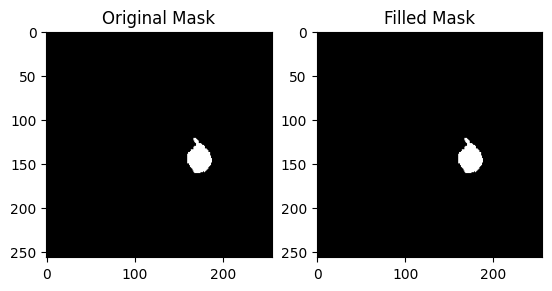

1.0 0.0
1 0


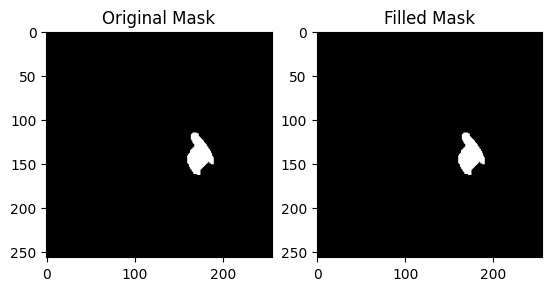

1.0 0.0
1 0


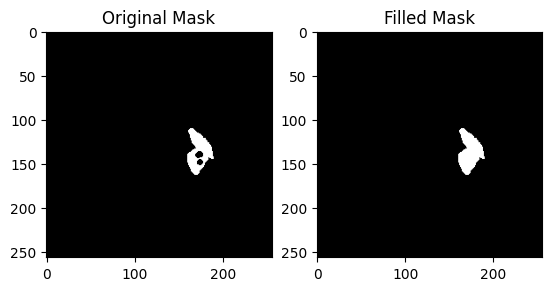

1.0 0.0
1 0


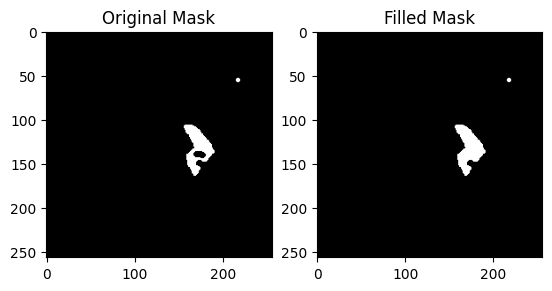

1.0 0.0
1 0


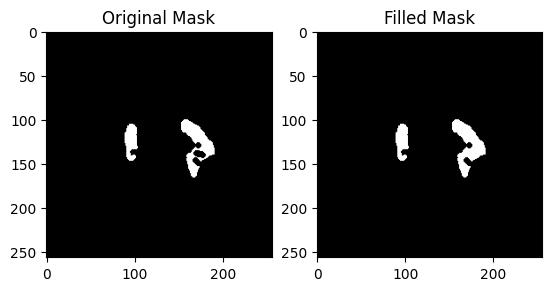

In [59]:
for i in range(5):
    tmp_mask = masks[i]
    filled_mask =  fill_holes(tmp_mask)
    # fill nan with zeros
    filled_mask = np.nan_to_num(filled_mask)
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(tmp_mask, cmap='gray')
    ax[0].set_title('Original Mask')
    ax[1].imshow(filled_mask, cmap='gray')
    ax[1].set_title('Filled Mask')

    print(np.max(tmp_mask), np.min(tmp_mask))
    print(np.max(filled_mask), np.min(filled_mask))
    plt.show()

In [62]:
def prepare_masks_and_save(mask_path):
    masks = np.load(mask_path)
    filled_masks = np.zeros_like(masks)
    for i in range(masks.shape[0]):
        tmp_mask = masks[i]
        filled_mask =  fill_holes(tmp_mask)
        filled_masks[i] = filled_mask
    return filled_masks


def fill_masks_and_save(mask_path, mask_path_out):
    filled_masks = prepare_masks_and_save(mask_path)
    # convert to numpy arary
    filled_masks = np.array(filled_masks)
    np.save(mask_path_out, filled_masks)

#fill_masks_and_save("../data/my_data2/test/DIXON_masks.npy", "../data/my_data2/test/DIXON_masks_filled.npy")


In [63]:
splits = ['train', 'val', 'test']
contrasts = ['DIXON', 'T1_mapping_fl2d', 'BOLD', 'Diffusion']

for split in splits:
    for contrast in contrasts:
        mask_path = f"../data/my_data2/{split}/{contrast}_masks.npy"
        mask_path_out = f"../data/my_data2/{split}/{contrast}_masks_filled.npy"
        fill_masks_and_save(mask_path, mask_path_out)

1.0 1.0


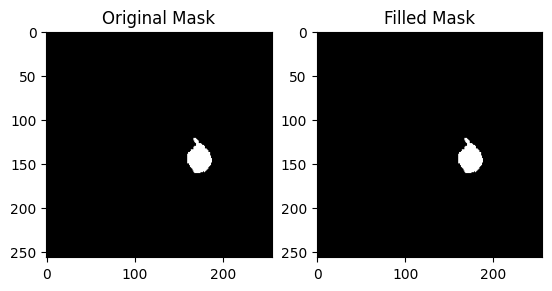

1.0 1.0


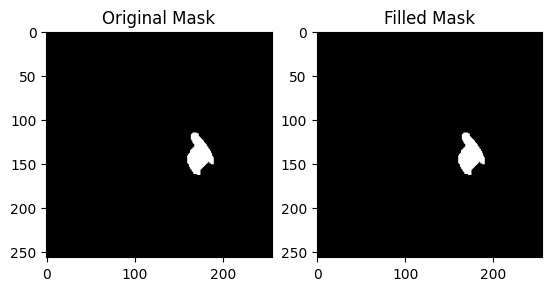

1.0 1.0


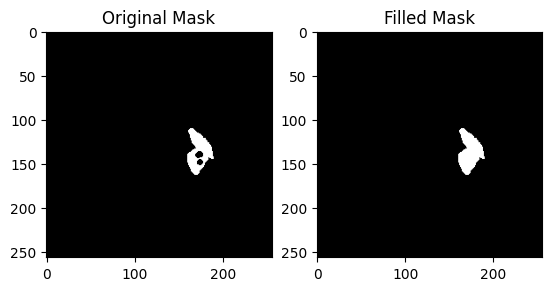

1.0 1.0


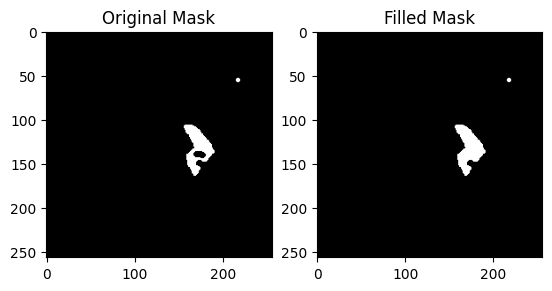

1.0 1.0


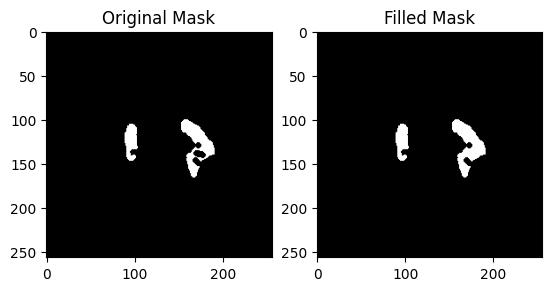

1.0 1.0


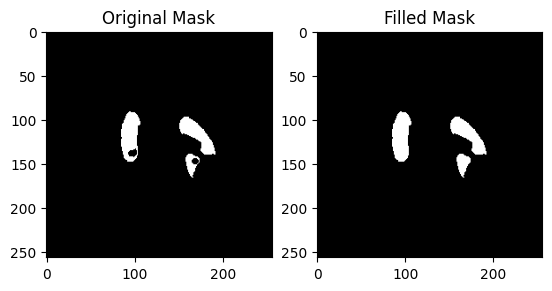

1.0 1.0


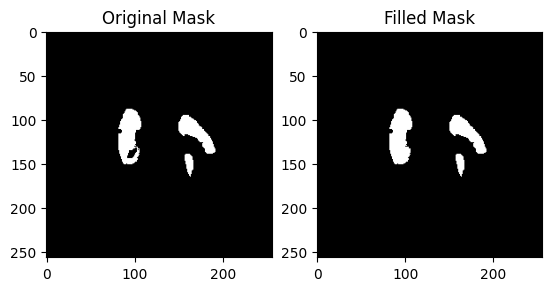

1.0 1.0


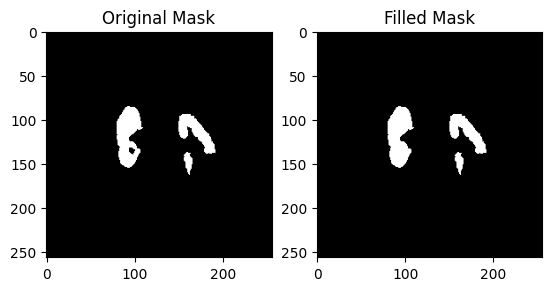

1.0 1.0


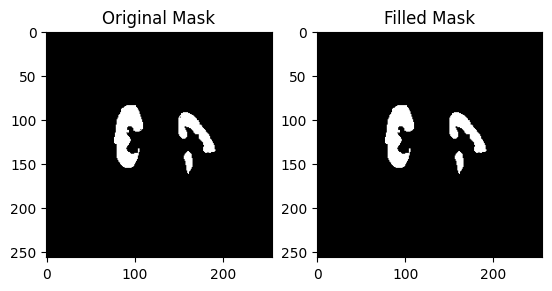

1.0 1.0


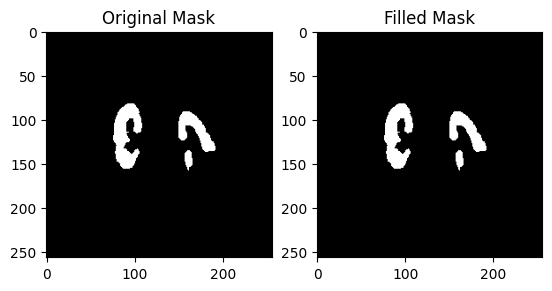

In [64]:
masks_path = "../data/my_data2/test/DIXON_masks.npy"
filled_masks = prepare_masks_and_save(masks_path)

for i in range(10):
    tmp_mask = masks[i]
    filled_mask =  filled_masks[i]
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(tmp_mask, cmap='gray')
    ax[0].set_title('Original Mask')
    ax[1].imshow(filled_mask, cmap='gray')
    ax[1].set_title('Filled Mask')
    print(np.max(tmp_mask), np.max(filled_mask))
    plt.show()